# Preprocessing Strategy Feature Importance Consistency

This notebook investigates how different preprocessing strategies affect feature importance consistency **within** the same algorithm.

Each algorithm is compared against itself across two preprocessing strategies:
- **SMOTE** (oversampling)
- **Undersampling** (random undersampling)

Comparisons are always **same algorithm, different strategy** — never cross-algorithm:
- Logistic Regression (SMOTE) vs Logistic Regression (Undersampling)
- Random Forest (SMOTE) vs Random Forest (Undersampling)
- XGBoost (SMOTE) vs XGBoost (Undersampling)
- Decision Tree (SMOTE) vs Decision Tree (Undersampling)

**Methods used:**
- Top-10 overlap — how many of the top 10 features are shared between the two strategies
- Spearman rank correlation — how similar the full feature rankings are between strategies
- Jaccard similarity — set-based overlap of the top-10 feature lists

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import spearmanr

plt.rcParams.update({
    'font.family':       'sans-serif',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'figure.dpi':        120,
})

os.makedirs("../results/figures/preprocessing_feature_consistency/", exist_ok=True)

MODEL_COLORS = {
    "Logistic Regression": "#3266ad",
    "Random Forest":        "#2a8a5e",
    "XGBoost":              "#a04e0a",
    "Decision Tree":        "#7a3090",
}
MODELS     = list(MODEL_COLORS.keys())
STRATEGIES = ["SMOTE", "Undersampling"]
TOP_N      = 10

## Loading SHAP Feature Importance Data

All feature importance CSV files are loaded and filtered to retain only SHAP results. Both preprocessing strategies (SMOTE and Undersampling) are kept, since the comparison here is **between** strategies within the same model.

In [2]:
files = glob.glob("../results/**/*_feature_importance.csv")

if not files:
    raise FileNotFoundError("No feature importance files found. Run all model notebooks first.")

raw_df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

# Keep only SHAP results
shap_df = raw_df[raw_df["Method"] == "SHAP"].copy()

print("Models found:     ", shap_df["Model"].unique())
print("Strategies found: ", shap_df["Strategy"].unique())
print("Total rows:       ", len(shap_df))

Models found:      ['Logistic Regression' 'XGBoost' 'Decision Tree' 'Random Forest']
Strategies found:  ['Undersampling' 'SMOTE']
Total rows:        344


## Helper Functions

The same three consistency metrics used in the model-comparison notebook, now applied **across strategies within a model** instead of across models within a strategy:

- `top_n_overlap` — count of shared features in the top N
- `spearman_correlation` — Spearman rank correlation over the full feature ranking
- `jaccard_similarity` — size of intersection divided by size of union for the top N feature sets

In [3]:
def get_top_n(df, model, strategy, n=TOP_N):
    """Return the top-N feature names for a given model and strategy."""
    subset = df[(df["Model"] == model) & (df["Strategy"] == strategy)]
    return set(subset.nsmallest(n, "Rank")["Feature"].tolist())


def get_full_ranking(df, model, strategy):
    """Return a Series of rank values indexed by feature."""
    subset = df[(df["Model"] == model) & (df["Strategy"] == strategy)]
    return subset.set_index("Feature")["Rank"].sort_values()


def top_n_overlap(df, model, strategy_a, strategy_b, n=TOP_N):
    """Number of shared features in the top N between two preprocessing strategies."""
    top_a = get_top_n(df, model, strategy_a, n)
    top_b = get_top_n(df, model, strategy_b, n)
    return len(top_a & top_b)


def spearman_correlation(df, model, strategy_a, strategy_b):
    """Spearman rank correlation of full feature rankings between two preprocessing strategies."""
    rank_a = get_full_ranking(df, model, strategy_a)
    rank_b = get_full_ranking(df, model, strategy_b)
    common = rank_a.index.intersection(rank_b.index)
    if len(common) < 2:
        return np.nan
    corr, _ = spearmanr(rank_a[common], rank_b[common])
    return round(corr, 4)


def jaccard_similarity(df, model, strategy_a, strategy_b, n=TOP_N):
    """Jaccard similarity of top-N feature sets between two preprocessing strategies."""
    top_a = get_top_n(df, model, strategy_a, n)
    top_b = get_top_n(df, model, strategy_b, n)
    if not top_a | top_b:
        return 0.0
    return round(len(top_a & top_b) / len(top_a | top_b), 4)


def compute_all_metrics(df, models=MODELS,
                        strategy_a="SMOTE", strategy_b="Undersampling", n=TOP_N):
    """Compute all three metrics for every model and return a summary DataFrame."""
    rows = []
    for model in models:
        has_a = not df[(df["Model"] == model) & (df["Strategy"] == strategy_a)].empty
        has_b = not df[(df["Model"] == model) & (df["Strategy"] == strategy_b)].empty
        if not (has_a and has_b):
            continue
        rows.append({
            "Model":       model,
            "Strategy A":  strategy_a,
            "Strategy B":  strategy_b,
            "Top-N Overlap":       top_n_overlap(df, model, strategy_a, strategy_b, n),
            "Spearman ρ":          spearman_correlation(df, model, strategy_a, strategy_b),
            "Jaccard Similarity":  jaccard_similarity(df, model, strategy_a, strategy_b, n),
        })
    return pd.DataFrame(rows)

---
# Section 1 — Top-10 Feature Rankings in a 4×2 Grid

This figure shows the top 10 SHAP features for each algorithm under both preprocessing strategies in a single paper-friendly layout. Rows represent the models and columns represent the preprocessing strategies. This makes the two strategy-specific rankings directly comparable for each model while keeping the strategies in consistent columns.

Features highlighted in the model color appear in the top 10 for both SMOTE and Undersampling; grey features are unique to that strategy.


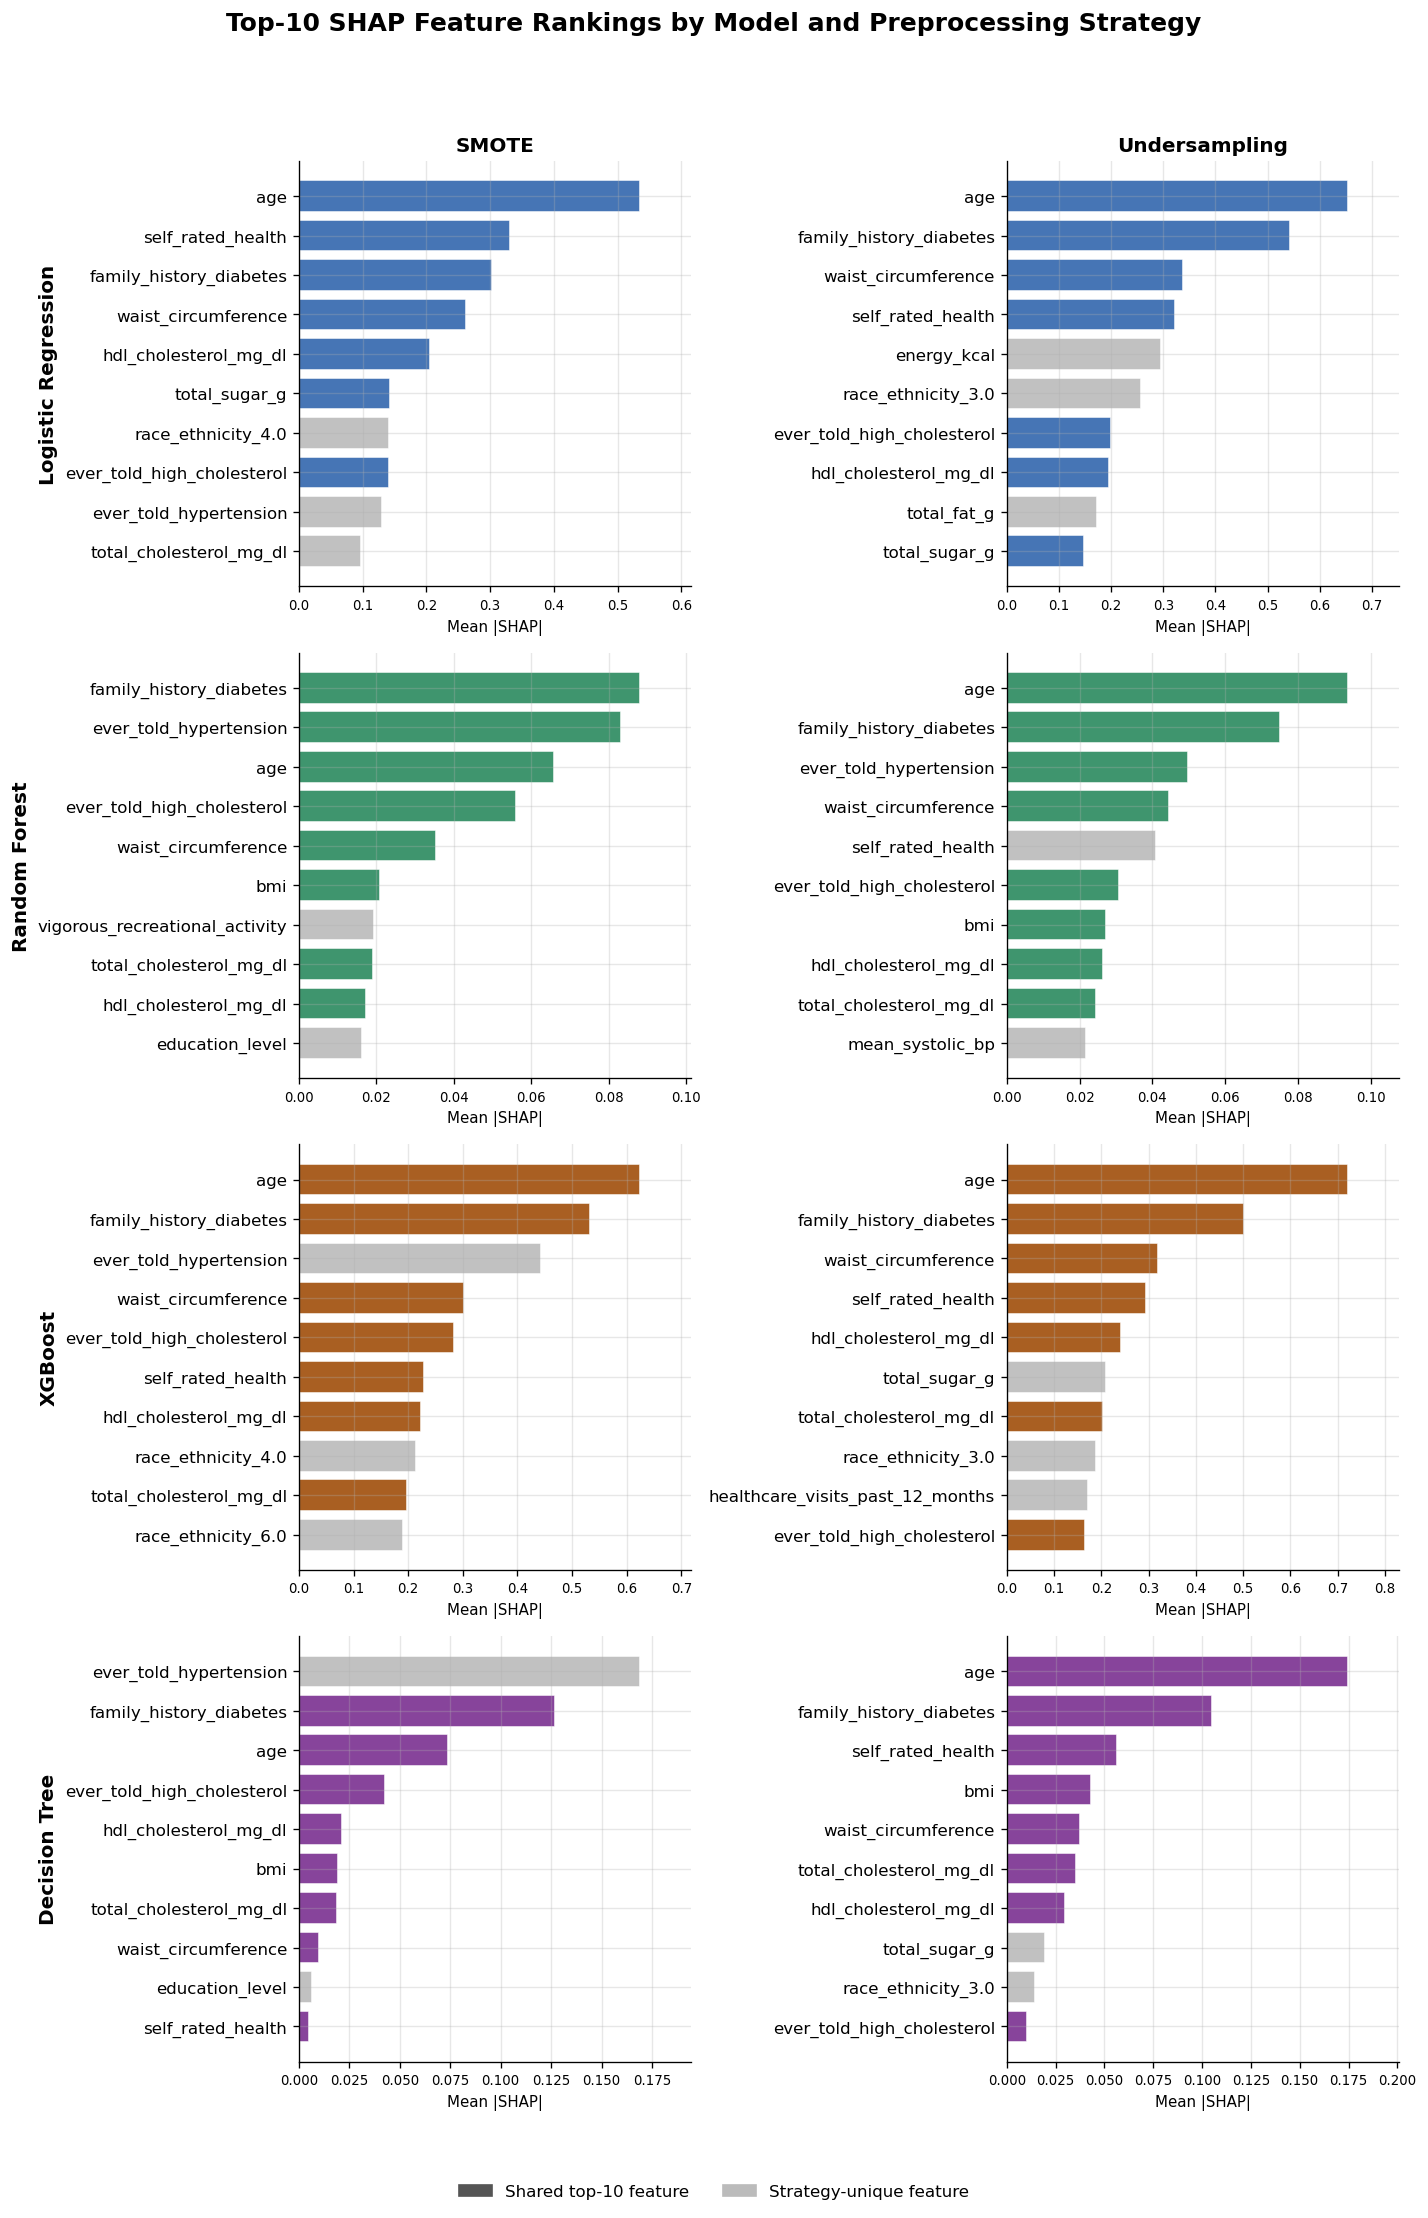

In [4]:
fig, axes = plt.subplots(
    nrows=len(MODELS),
    ncols=len(STRATEGIES),
    figsize=(12, 18),
    sharex=False,
    sharey=False
)

if len(MODELS) == 1 and len(STRATEGIES) == 1:
    axes = np.array([[axes]])
elif len(MODELS) == 1:
    axes = np.array([axes])
elif len(STRATEGIES) == 1:
    axes = np.array([[ax] for ax in axes])

for row_idx, model in enumerate(MODELS):
    for col_idx, strategy in enumerate(STRATEGIES):
        ax = axes[row_idx, col_idx]
        color = MODEL_COLORS[model]

        subset = shap_df[
            (shap_df["Model"] == model) &
            (shap_df["Strategy"] == strategy)
        ].nsmallest(TOP_N, "Rank")

        if subset.empty:
            if row_idx == 0:
                ax.set_title(strategy, fontsize=12, fontweight="bold")
            if col_idx == 0:
                ax.set_ylabel(model, fontsize=12, fontweight="bold")
            ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
            ax.set_axis_off()
            continue

        subset = subset.sort_values("Importance", ascending=True)

        top_smote = get_top_n(shap_df, model, "SMOTE", TOP_N)
        top_under = get_top_n(shap_df, model, "Undersampling", TOP_N)
        shared = top_smote & top_under

        bar_colors = [color if feature in shared else "#bbbbbb" for feature in subset["Feature"]]

        ax.barh(
            subset["Feature"],
            subset["Importance"],
            color=bar_colors,
            edgecolor="white",
            alpha=0.9
        )

        if row_idx == 0:
            ax.set_title(strategy, fontsize=12, fontweight="bold")

        if col_idx == 0:
            ax.set_ylabel(model, fontsize=12, fontweight="bold")
        else:
            ax.set_ylabel("")

        ax.set_xlabel("Mean |SHAP|", fontsize=9)
        ax.tick_params(axis="y", labelsize=10)
        ax.tick_params(axis="x", labelsize=8)

        max_val = subset["Importance"].max()
        ax.set_xlim(0, max_val * 1.15 if max_val > 0 else 1)

shared_patch = mpatches.Patch(color="#555555", label=f"Shared top-{TOP_N} feature")
unique_patch = mpatches.Patch(color="#bbbbbb", label="Strategy-unique feature")

fig.legend(
    handles=[shared_patch, unique_patch],
    loc="lower center",
    ncol=2,
    fontsize=10,
    bbox_to_anchor=(0.5, -0.01),
    frameon=False
)

fig.suptitle(
    f"Top-{TOP_N} SHAP Feature Rankings by Model and Preprocessing Strategy",
    fontsize=15,
    fontweight="bold",
    y=1.01
)

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.savefig(
    "../results/figures/preprocessing_feature_consistency/top10_rankings_4x2_grid.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()


---
# Section 2 — Top-10 Overlap per Algorithm

Each bar shows how many of the top 10 SHAP features are shared between SMOTE and Undersampling **for the same algorithm**. A value of 10 means the top-10 list is identical regardless of preprocessing strategy; 0 means no overlap at all.

This directly answers: *does preprocessing strategy change which features a model considers most important?*

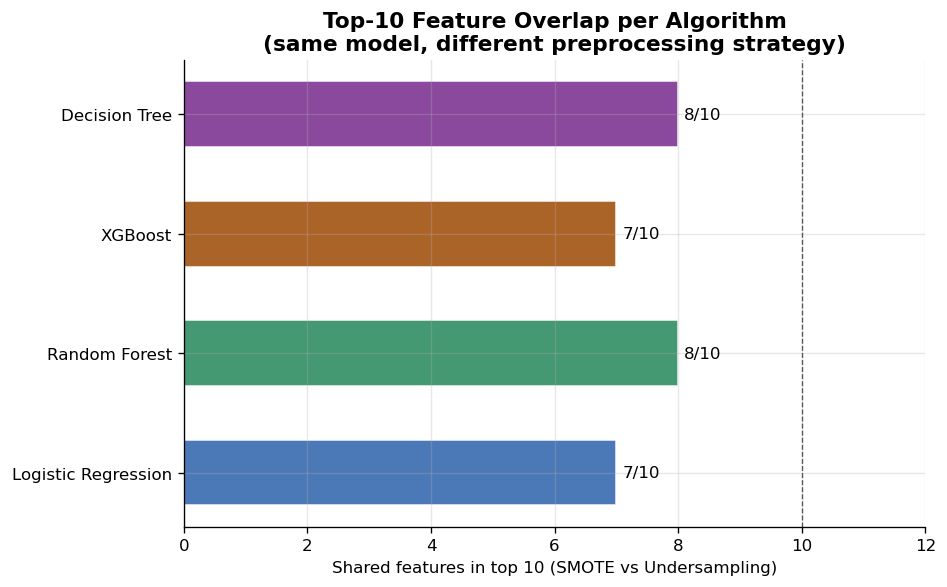

Mean top-10 overlap across algorithms: 7.50


In [5]:
summary_df = compute_all_metrics(shap_df)

fig, ax = plt.subplots(figsize=(8, 5))

bar_colors = [MODEL_COLORS.get(m, "#888888") for m in summary_df["Model"]]
bars = ax.barh(summary_df["Model"], summary_df["Top-N Overlap"],
               color=bar_colors, edgecolor="white", alpha=0.88, height=0.55)

# Annotate values
for bar, val in zip(bars, summary_df["Top-N Overlap"]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            f"{int(val)}/{TOP_N}", va="center", ha="left", fontsize=10)

ax.axvline(x=TOP_N, color="#555", linestyle="--", linewidth=0.8, label="Perfect overlap")
ax.set_xlim(0, TOP_N + 2)
ax.set_xlabel(f"Shared features in top {TOP_N} (SMOTE vs Undersampling)", fontsize=10)
ax.set_title(f"Top-{TOP_N} Feature Overlap per Algorithm\n(same model, different preprocessing strategy)",
             fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("../results/figures/preprocessing_feature_consistency/top10_overlap_bar.png", bbox_inches="tight")
plt.show()

print(f"Mean top-{TOP_N} overlap across algorithms: {summary_df['Top-N Overlap'].mean():.2f}")

---
# Section 3 — Spearman Rank Correlation per Algorithm

Spearman rank correlation is computed over **all** features (not just the top 10), comparing the full rank order produced by SMOTE vs Undersampling **within each algorithm**.

- ρ = 1.0 → identical ranking regardless of preprocessing strategy
- ρ = 0.0 → no correlation between strategies
- ρ < 0.0 → strategies produce inverse orderings

This is a stricter measure than top-10 overlap because it evaluates stability across the entire feature set.

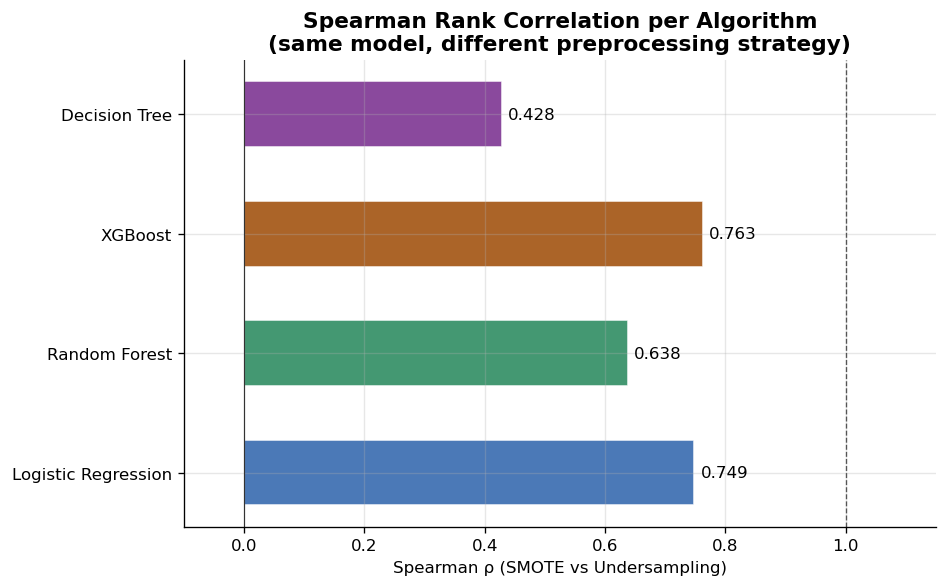

Mean Spearman ρ across algorithms: 0.645
Min: 0.428  Max: 0.763


In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

bar_colors = [MODEL_COLORS.get(m, "#888888") for m in summary_df["Model"]]
bars = ax.barh(summary_df["Model"], summary_df["Spearman ρ"],
               color=bar_colors, edgecolor="white", alpha=0.88, height=0.55)

for bar, val in zip(bars, summary_df["Spearman ρ"]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", ha="left", fontsize=10)

ax.axvline(x=0, color="#333", linewidth=0.7)
ax.axvline(x=1, color="#555", linestyle="--", linewidth=0.8, label="Perfect correlation")
ax.set_xlim(-0.1, 1.15)
ax.set_xlabel("Spearman ρ (SMOTE vs Undersampling)", fontsize=10)
ax.set_title("Spearman Rank Correlation per Algorithm\n(same model, different preprocessing strategy)",
             fontsize=13, fontweight="bold")


plt.tight_layout()
plt.savefig("../results/figures/preprocessing_feature_consistency/spearman_bar.png", bbox_inches="tight")
plt.show()

print(f"Mean Spearman ρ across algorithms: {summary_df['Spearman ρ'].mean():.3f}")
print(f"Min: {summary_df['Spearman ρ'].min():.3f}  Max: {summary_df['Spearman ρ'].max():.3f}")

---
# Section 4 — Jaccard Similarity per Algorithm

Jaccard similarity is the ratio of the intersection to the union of the top-10 feature sets produced by SMOTE and Undersampling for the same algorithm.

- J = 1.0 → identical top-10 sets regardless of preprocessing
- J = 0.0 → no features in common in the top 10

Compared to the raw overlap count, Jaccard is normalised to [0, 1] and accounts for the full union — making it easier to compare across experiments with different feature set sizes.

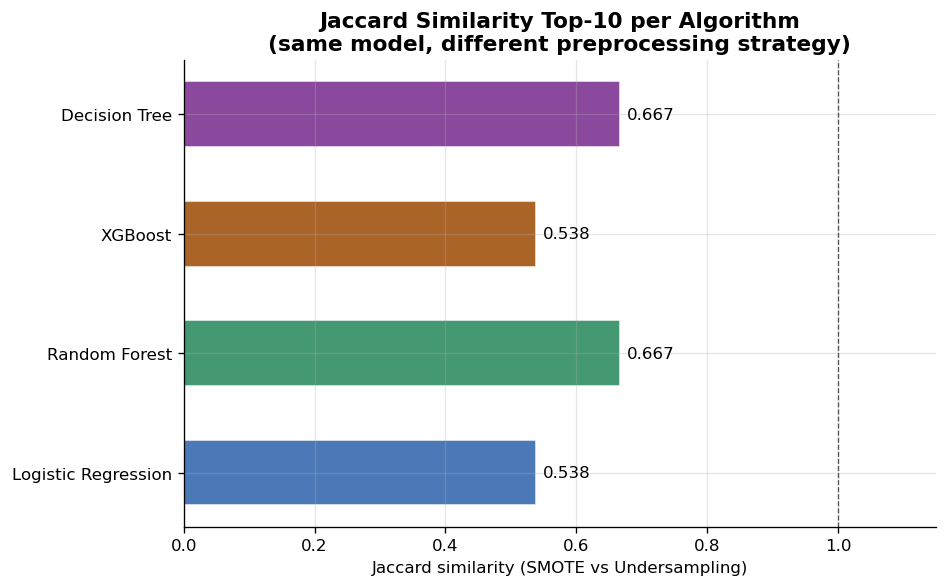

Mean Jaccard similarity across algorithms: 0.603


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

bar_colors = [MODEL_COLORS.get(m, "#888888") for m in summary_df["Model"]]
bars = ax.barh(summary_df["Model"], summary_df["Jaccard Similarity"],
               color=bar_colors, edgecolor="white", alpha=0.88, height=0.55)

for bar, val in zip(bars, summary_df["Jaccard Similarity"]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", ha="left", fontsize=10)

ax.axvline(x=1, color="#555", linestyle="--", linewidth=0.8, label="Perfect similarity")
ax.set_xlim(0, 1.15)
ax.set_xlabel("Jaccard similarity (SMOTE vs Undersampling)", fontsize=10)
ax.set_title(f"Jaccard Similarity Top-{TOP_N} per Algorithm\n(same model, different preprocessing strategy)",
             fontsize=13, fontweight="bold")


plt.tight_layout()
plt.savefig("../results/figures/preprocessing_feature_consistency/jaccard_bar.png", bbox_inches="tight")
plt.show()

print(f"Mean Jaccard similarity across algorithms: {summary_df['Jaccard Similarity'].mean():.3f}")

---
# Section 5 — All Three Metrics Combined (Multi-Metric Overview)

A grouped bar chart that places all three normalised metrics side-by-side for each algorithm. Top-10 overlap is normalised to [0, 1] by dividing by N to make it comparable with Spearman ρ and Jaccard similarity.

This provides a single view for comparing consistency profiles across algorithms: an algorithm that scores high on all three metrics is robust to the choice of preprocessing strategy.

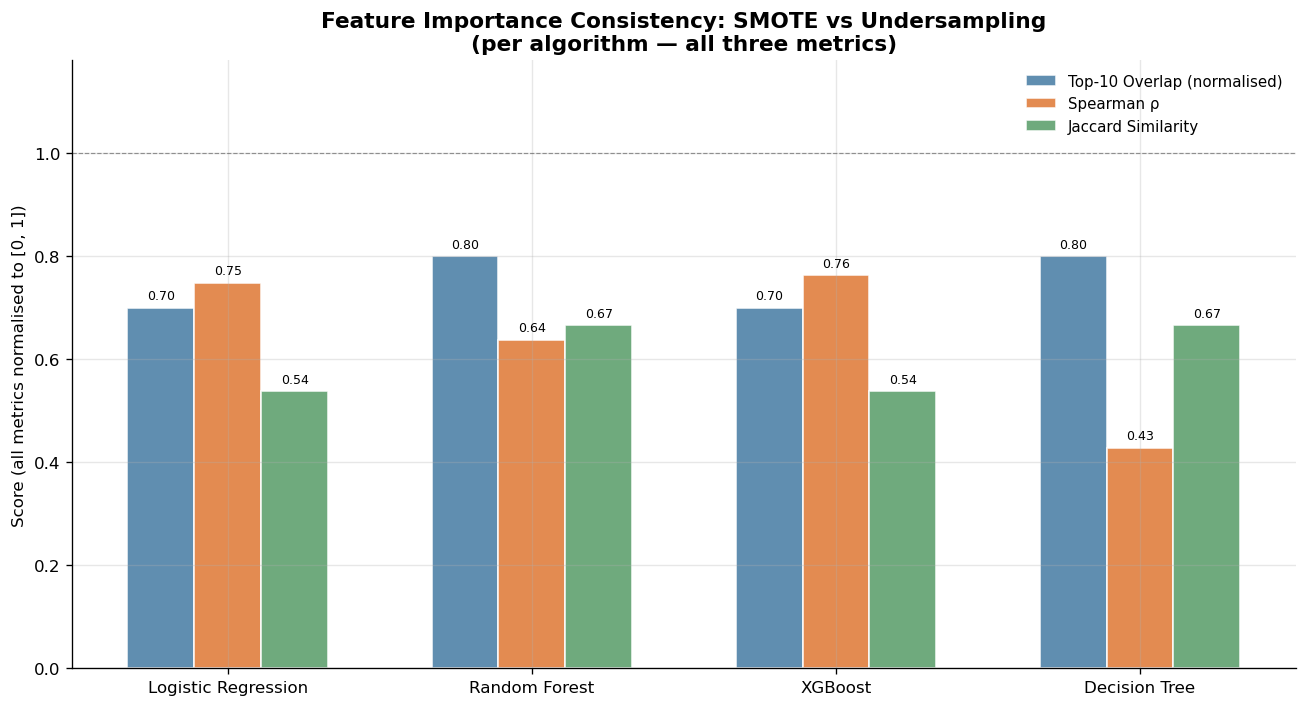

In [8]:
plot_df = summary_df.copy()
plot_df["Top-N Overlap (norm)"] = plot_df["Top-N Overlap"] / TOP_N

metrics       = ["Top-N Overlap (norm)", "Spearman ρ", "Jaccard Similarity"]
metric_labels = [f"Top-{TOP_N} Overlap (normalised)", "Spearman ρ", "Jaccard Similarity"]
metric_colors = ["#4a7fa5", "#e07b39", "#5b9e6b"]

n_models  = len(plot_df)
n_metrics = len(metrics)
x         = np.arange(n_models)
width     = 0.22

fig, ax = plt.subplots(figsize=(11, 6))

for i, (metric, label, mc) in enumerate(zip(metrics, metric_labels, metric_colors)):
    offset = (i - n_metrics / 2 + 0.5) * width
    bars = ax.bar(x + offset, plot_df[metric], width,
                  label=label, color=mc, edgecolor="white", alpha=0.88)
    for bar, val in zip(bars, plot_df[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f"{val:.2f}",
                ha="center", va="bottom", fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(plot_df["Model"], fontsize=10)
ax.set_ylim(0, 1.18)
ax.set_ylabel("Score (all metrics normalised to [0, 1])", fontsize=10)
ax.set_title("Feature Importance Consistency: SMOTE vs Undersampling\n(per algorithm — all three metrics)",
             fontsize=13, fontweight="bold")
ax.axhline(y=1.0, color="#555", linestyle="--", linewidth=0.7, alpha=0.6)
ax.legend(fontsize=9, frameon=False, loc="upper right")

plt.tight_layout()
plt.savefig("../results/figures/preprocessing_feature_consistency/multi_metric_overview.png", bbox_inches="tight")
plt.show()

---
# Section 6 — Summary Table

A single table summarising all three consistency metrics for every algorithm. Rows are sorted by Spearman ρ (descending) so the most preprocessing-stable algorithm appears first.

In [9]:
display_df = summary_df[[
    "Model", "Top-N Overlap", "Spearman ρ", "Jaccard Similarity"
]].copy()

display_df = display_df.sort_values("Spearman ρ", ascending=False).reset_index(drop=True)

display_df["Top-N Overlap"] = display_df["Top-N Overlap"].apply(
    lambda x: f"{int(x)}/{TOP_N}"
)

print(f"Preprocessing Strategy Consistency Summary — SMOTE vs Undersampling (Top-{TOP_N})")
print("="*70)
display(display_df)

print()
print("Overall means (excluding Top-N overlap count):")
print(f"  Spearman ρ:         {summary_df['Spearman ρ'].mean():.3f}")
print(f"  Jaccard Similarity: {summary_df['Jaccard Similarity'].mean():.3f}")
print(f"  Top-N Overlap:      {summary_df['Top-N Overlap'].mean():.1f} / {TOP_N}")

Preprocessing Strategy Consistency Summary — SMOTE vs Undersampling (Top-10)


,Model,Top-N Overlap,Spearman ρ,Jaccard Similarity
0,XGBoost,7/10,0.7634,0.5385
1,Logistic Regression,7/10,0.7486,0.5385
2,Random Forest,8/10,0.6379,0.6667
3,Decision Tree,8/10,0.4284,0.6667



Overall means (excluding Top-N overlap count):
  Spearman ρ:         0.645
  Jaccard Similarity: 0.603
  Top-N Overlap:      7.5 / 10


---
# Section 7 — Top-N Feature Set Overlap (Venn Diagrams)

A visual companion to the Jaccard similarity bar chart in Section 4. Each panel shows the top-N SHAP
feature set under SMOTE (left circle) and Undersampling (right circle) for one algorithm, with the shared
features in the intersection. Circle sizes are stylised rather than area-proportional; the counts in each
region are exact.

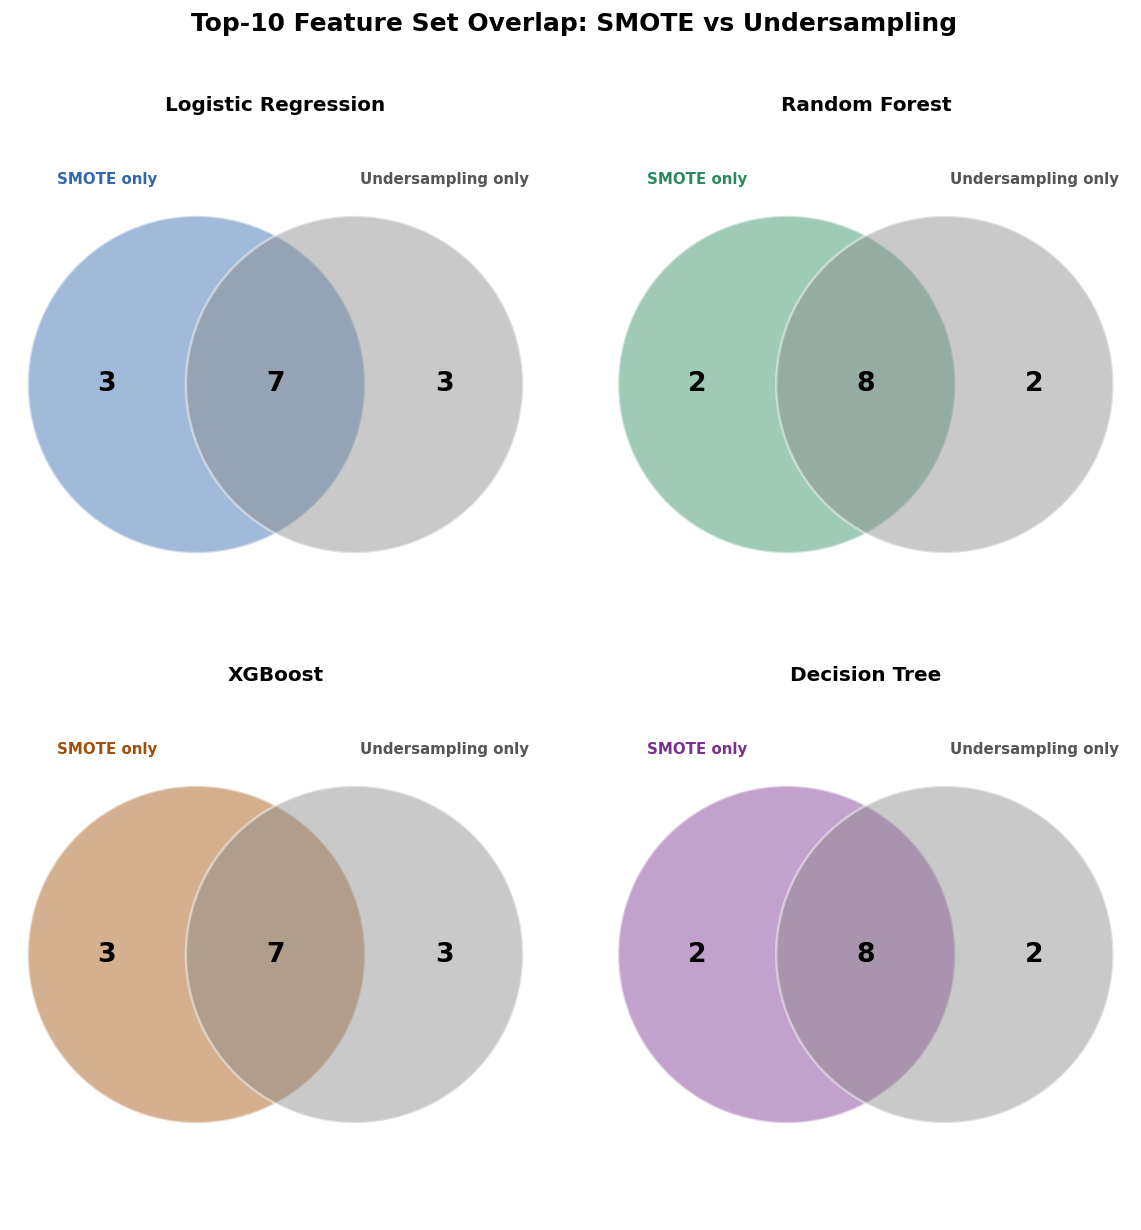

In [10]:
from matplotlib.patches import Circle

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for idx, model in enumerate(MODELS):
    ax = axes[idx]
    color = MODEL_COLORS[model]

    top_smote = get_top_n(shap_df, model, "SMOTE", TOP_N)
    top_under = get_top_n(shap_df, model, "Undersampling", TOP_N)

    if not top_smote and not top_under:
        ax.set_title(model, fontsize=12, fontweight="bold")
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        continue

    shared = top_smote & top_under
    only_smote = top_smote - top_under
    only_under = top_under - top_smote

    ax.add_patch(Circle((0.35, 0.5), 0.32, color=color, alpha=0.45, ec="white", lw=1.5))
    ax.add_patch(Circle((0.65, 0.5), 0.32, color="#888888", alpha=0.45, ec="white", lw=1.5))

    ax.text(0.18, 0.5, str(len(only_smote)), ha="center", va="center", fontsize=16, fontweight="bold")
    ax.text(0.50, 0.5, str(len(shared)), ha="center", va="center", fontsize=16, fontweight="bold")
    ax.text(0.82, 0.5, str(len(only_under)), ha="center", va="center", fontsize=16, fontweight="bold")

    ax.text(0.18, 0.88, "SMOTE only", ha="center", fontsize=9, color=color, fontweight="bold")
    ax.text(0.82, 0.88, "Undersampling only", ha="center", fontsize=9, color="#555555", fontweight="bold")

    ax.set_title(model, fontsize=12, fontweight="bold")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.set_axis_off()

fig.suptitle(
    f"Top-{TOP_N} Feature Set Overlap: SMOTE vs Undersampling",
    fontsize=15, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig(
    "../results/figures/preprocessing_feature_consistency/top10_venn.png",
    bbox_inches="tight", dpi=300
)
plt.show()

---
# Section 8 — Feature Rank Movement (Bump Chart)

A slope chart connecting each feature's rank under SMOTE (left) to its rank under Undersampling (right),
restricted to the union of each strategy's top-N. Flat, near-horizontal lines indicate a feature whose
importance ranking barely moved between strategies; steep lines indicate a feature that became much more or
less important depending on how class imbalance was handled.

Lines are drawn in the model colour when the feature is in the top-N under **both** strategies, and in
grey when it only made the cut under one strategy.

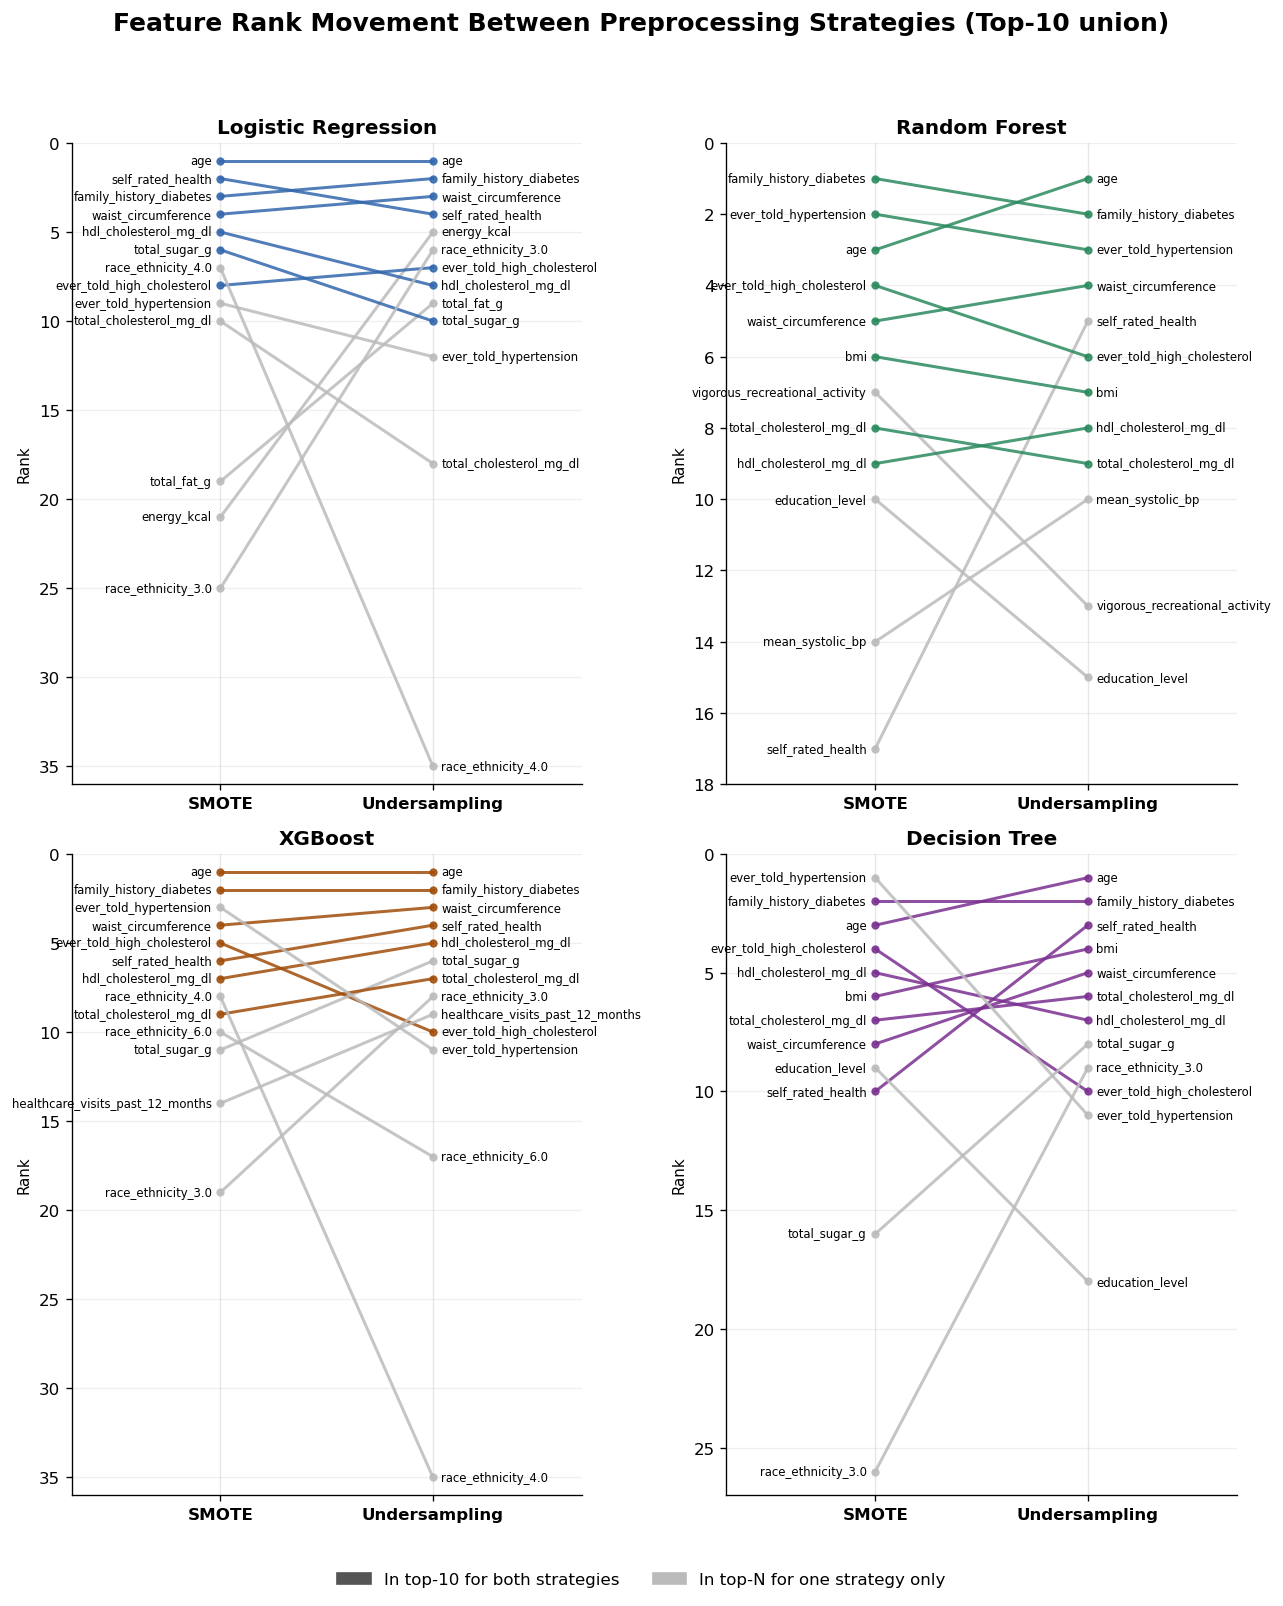

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(11, 13))
axes = axes.flatten()

for idx, model in enumerate(MODELS):
    ax = axes[idx]
    color = MODEL_COLORS[model]

    rank_smote = get_full_ranking(shap_df, model, "SMOTE")
    rank_under = get_full_ranking(shap_df, model, "Undersampling")

    top_smote = get_top_n(shap_df, model, "SMOTE", TOP_N)
    top_under = get_top_n(shap_df, model, "Undersampling", TOP_N)
    features = top_smote | top_under

    if not features:
        ax.set_title(model, fontsize=12, fontweight="bold")
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        continue

    shared = top_smote & top_under
    max_rank_seen = 1

    for feat in features:
        if feat not in rank_smote.index or feat not in rank_under.index:
            continue
        y0, y1 = rank_smote[feat], rank_under[feat]
        max_rank_seen = max(max_rank_seen, y0, y1)
        line_color = color if feat in shared else "#bbbbbb"

        ax.plot([0, 1], [y0, y1], color=line_color, linewidth=1.8, alpha=0.85,
                marker="o", markersize=4, zorder=2)
        ax.text(-0.04, y0, feat, ha="right", va="center", fontsize=7)
        ax.text(1.04, y1, feat, ha="left", va="center", fontsize=7)

    ax.set_xlim(-0.7, 1.7)
    ax.set_ylim(max_rank_seen + 1, 0)  # inverted so rank 1 is at the top
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["SMOTE", "Undersampling"], fontsize=10, fontweight="bold")
    ax.set_ylabel("Rank", fontsize=9)
    ax.set_title(model, fontsize=12, fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.2)

shared_patch = mpatches.Patch(color="#555555", label=f"In top-{TOP_N} for both strategies")
unique_patch = mpatches.Patch(color="#bbbbbb", label="In top-N for one strategy only")
fig.legend(
    handles=[shared_patch, unique_patch], loc="lower center", ncol=2, fontsize=10,
    bbox_to_anchor=(0.5, -0.01), frameon=False
)

fig.suptitle(
    f"Feature Rank Movement Between Preprocessing Strategies (Top-{TOP_N} union)",
    fontsize=15, fontweight="bold", y=1.01
)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.savefig(
    "../results/figures/preprocessing_feature_consistency/rank_bump_chart.png",
    bbox_inches="tight", dpi=300
)
plt.show()